# Notebook 06: Climate Analysis
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Study long-term climate patterns, regional variations, and temperature trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR    = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")
print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")

Loaded: (144822, 39)
Date range: 2024-05-16 01:45:00 → 2026-06-01 19:15:00


## 1. Long-Term Temperature Trend

Temperature trend: -0.2374°C per month
R²: 0.2579 | p-value: 0.0081
Over 26 months: -6.17°C total change


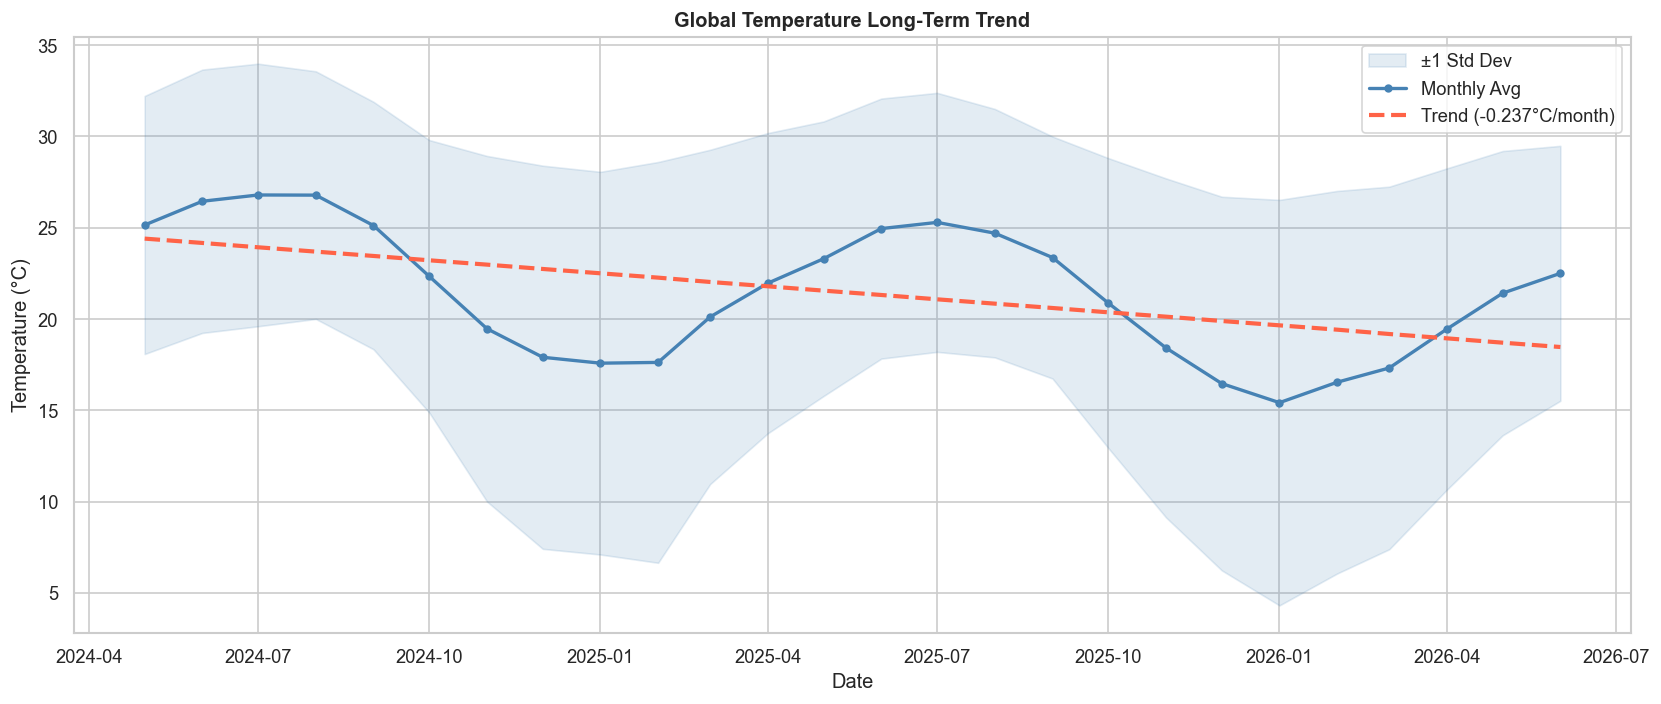

Saved: 28_long_term_trend.png


In [2]:
# Monthly global average
monthly = df.groupby(df['last_updated'].dt.to_period('M')).agg(
    temp_mean=('temperature_celsius', 'mean'),
    temp_std=('temperature_celsius', 'std'),
    record_count=('temperature_celsius', 'count')
).reset_index()
monthly['last_updated'] = monthly['last_updated'].dt.to_timestamp()
monthly['month_num'] = np.arange(len(monthly))

# Linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(
    monthly['month_num'], monthly['temp_mean']
)
trend_line = slope * monthly['month_num'] + intercept

print(f"Temperature trend: {slope:+.4f}°C per month")
print(f"R²: {r_value**2:.4f} | p-value: {p_value:.4f}")
print(f"Over {len(monthly)} months: {slope*len(monthly):+.2f}°C total change")

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(monthly['last_updated'],
                monthly['temp_mean'] - monthly['temp_std'],
                monthly['temp_mean'] + monthly['temp_std'],
                alpha=0.15, color='steelblue', label='±1 Std Dev')
ax.plot(monthly['last_updated'], monthly['temp_mean'],
        color='steelblue', linewidth=2, marker='o', markersize=4, label='Monthly Avg')
ax.plot(monthly['last_updated'], trend_line,
        color='tomato', linewidth=2.5, linestyle='--',
        label=f'Trend ({slope:+.3f}°C/month)')
ax.set_title('Global Temperature Long-Term Trend', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '28_long_term_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 28_long_term_trend.png")

## 2. Temperature Trends by Continent

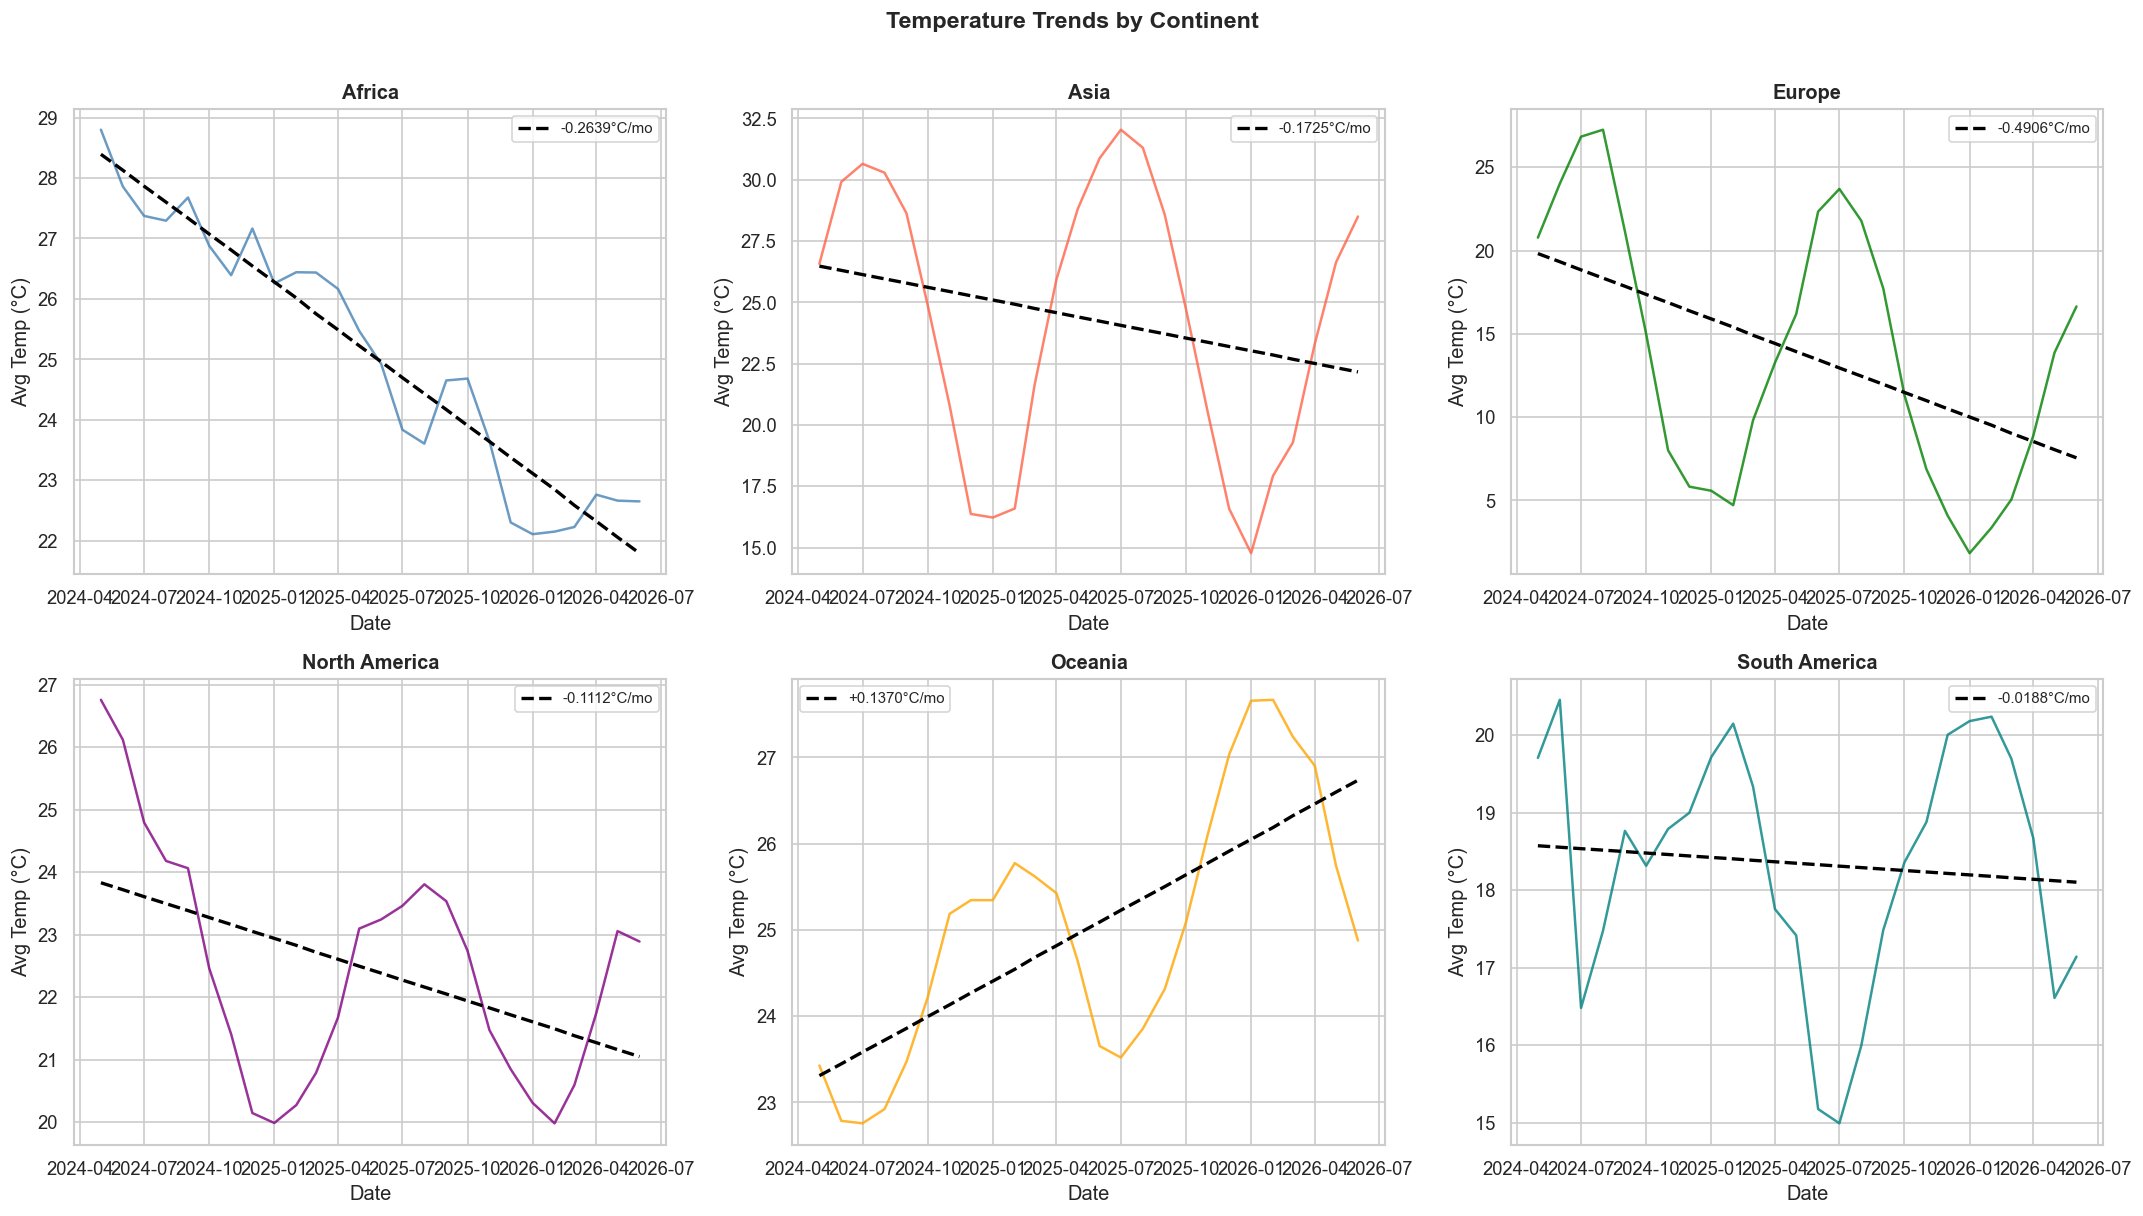


Continent Temperature Trends:
    Continent  Slope (°C/month)     R²  p-value
       Africa           -0.2639 0.9206   0.0000
         Asia           -0.1725 0.0553   0.2475
       Europe           -0.4906 0.2215   0.0152
North America           -0.1112 0.2067   0.0196
      Oceania            0.1370 0.4921   0.0001
South America           -0.0188 0.0083   0.6589
Saved: 29_continent_trends.png


In [3]:
continents = df['continent'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = ['steelblue','tomato','green','purple','orange','teal']

continent_trends = []

for i, continent in enumerate(sorted(continents)):
    subset = df[df['continent'] == continent]
    monthly_c = subset.groupby(
        subset['last_updated'].dt.to_period('M')
    )['temperature_celsius'].mean().reset_index()
    monthly_c['last_updated'] = monthly_c['last_updated'].dt.to_timestamp()
    monthly_c['month_num'] = np.arange(len(monthly_c))

    slope, intercept, r_val, p_val, _ = stats.linregress(
        monthly_c['month_num'], monthly_c['temperature_celsius']
    )
    trend = slope * monthly_c['month_num'] + intercept
    continent_trends.append({
        'Continent': continent,
        'Slope (°C/month)': round(slope, 4),
        'R²': round(r_val**2, 4),
        'p-value': round(p_val, 4)
    })

    axes[i].plot(monthly_c['last_updated'],
                 monthly_c['temperature_celsius'],
                 color=colors[i], linewidth=1.5, alpha=0.8)
    axes[i].plot(monthly_c['last_updated'], trend,
                 color='black', linewidth=2, linestyle='--',
                 label=f'{slope:+.4f}°C/mo')
    axes[i].set_title(continent, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Avg Temp (°C)')
    axes[i].legend(fontsize=9)

plt.suptitle('Temperature Trends by Continent', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '29_continent_trends.png', dpi=150, bbox_inches='tight')
plt.show()

trends_df = pd.DataFrame(continent_trends)
print("\nContinent Temperature Trends:")
print(trends_df.to_string(index=False))
print("Saved: 29_continent_trends.png")

## 3. Seasonal Heatmap by Country

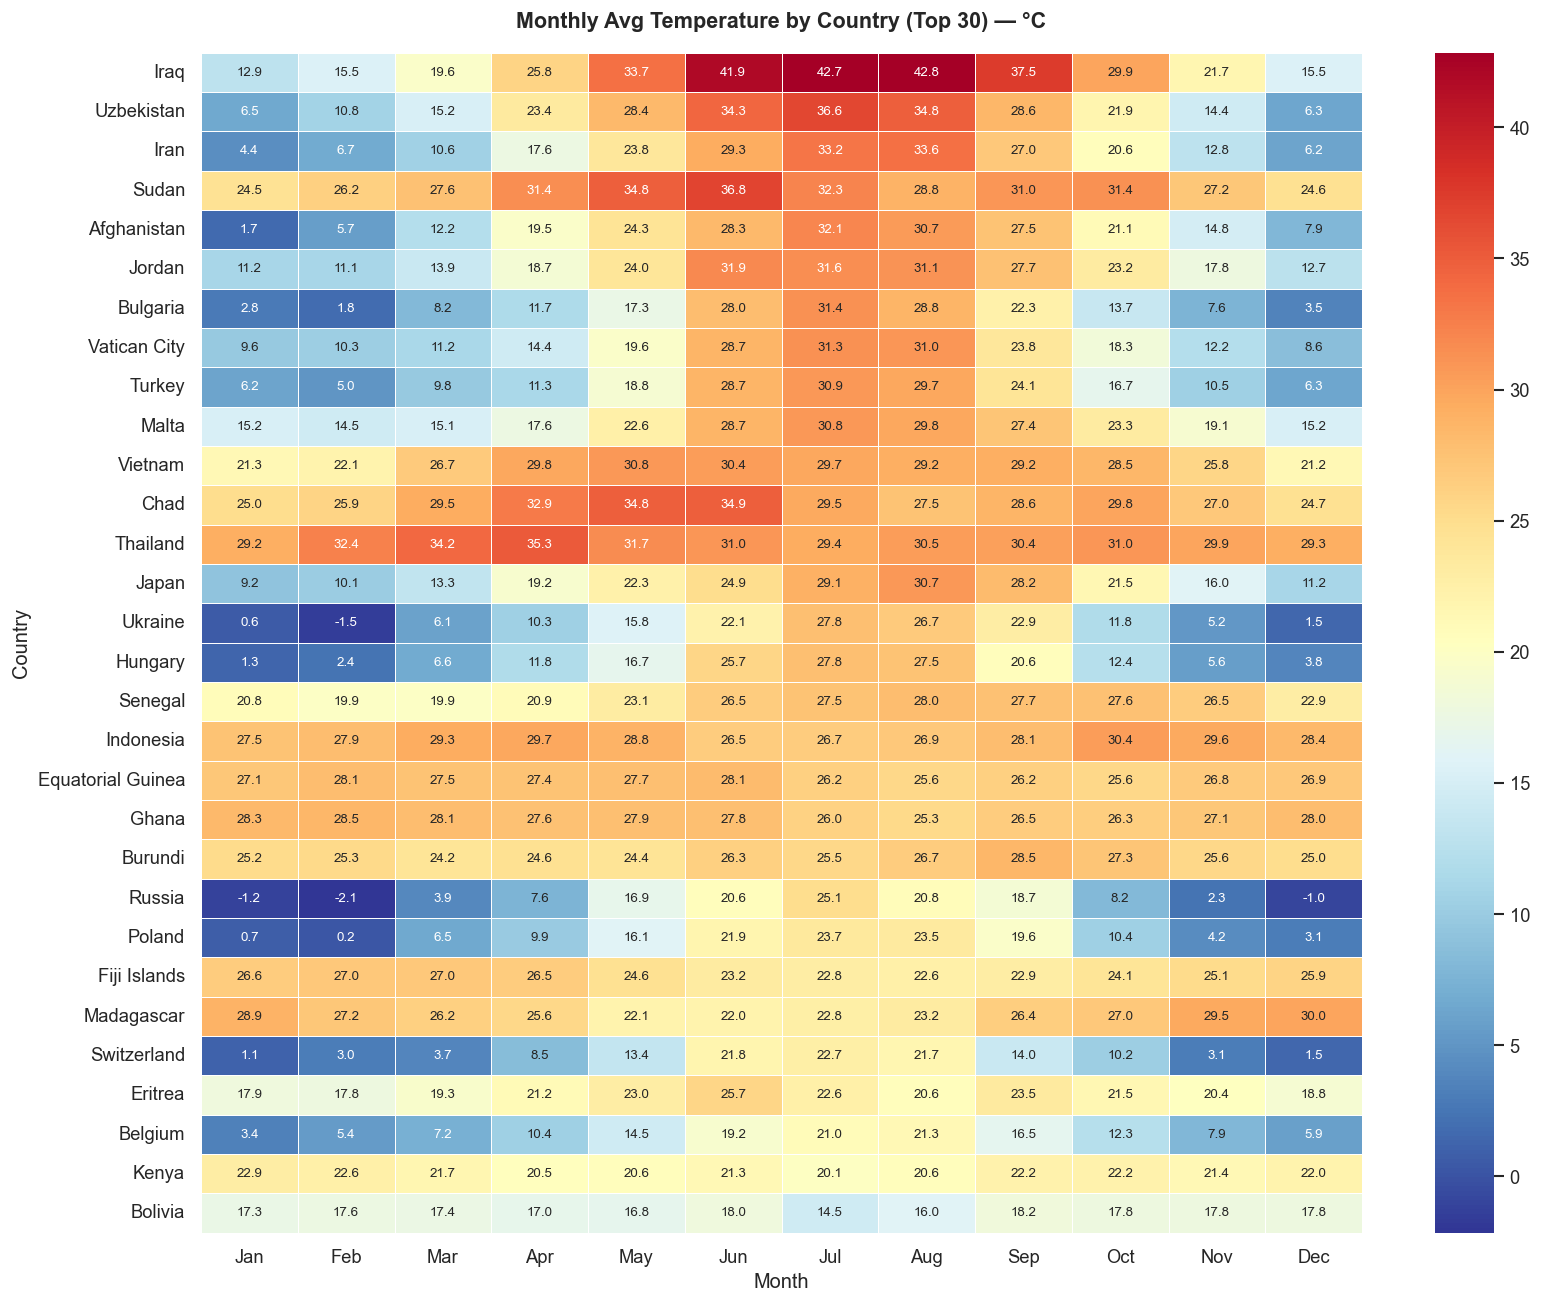

Saved: 30_seasonal_heatmap_country.png


In [4]:
# Top 30 countries by record count
top_countries = df['country'].value_counts().head(30).index
df_top = df[df['country'].isin(top_countries)]

pivot = df_top.pivot_table(
    values='temperature_celsius',
    index='country',
    columns='month',
    aggfunc='mean'
)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot.sort_values('Jul', ascending=False)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.3, ax=ax, annot_kws={'size': 8})
ax.set_title('Monthly Avg Temperature by Country (Top 30) — °C',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '30_seasonal_heatmap_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 30_seasonal_heatmap_country.png")

## 4. Climate Zones Analysis

Climate Zone Statistics:
                        avg_temp  avg_humidity  avg_precip  avg_wind  count
climate_zone                                                               
Polar (60-90°)              7.50         77.00        0.02     19.20   1486
Subtropical (23.5-35°)     23.93         51.57        0.01     13.20  21267
Temperate (35-60°)         14.71         64.84        0.01     12.34  50068
Tropical (0-23.5°)         25.49         72.42        0.02     12.72  72001


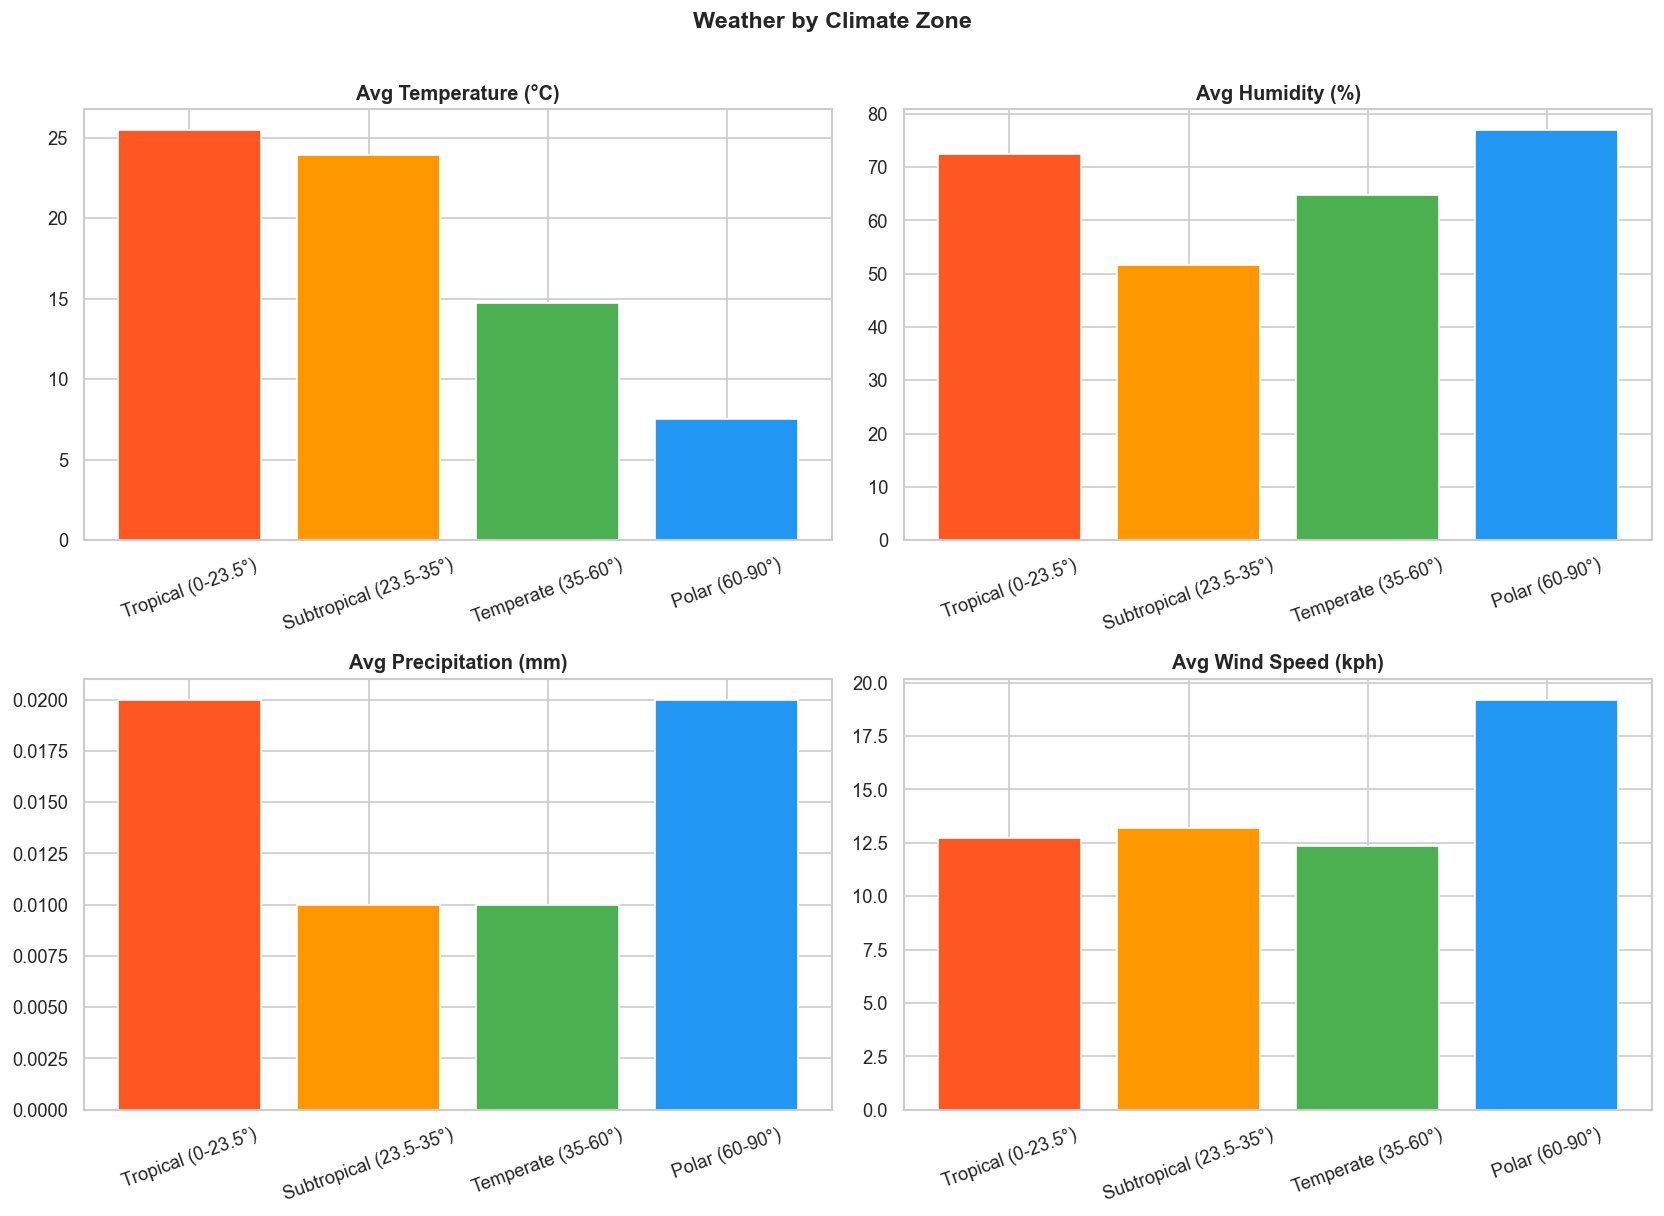

Saved: 31_climate_zones.png


In [5]:
# Classify locations into climate zones by latitude
def classify_climate(lat):
    lat = abs(lat)
    if lat <= 23.5:
        return 'Tropical (0-23.5°)'
    elif lat <= 35:
        return 'Subtropical (23.5-35°)'
    elif lat <= 60:
        return 'Temperate (35-60°)'
    else:
        return 'Polar (60-90°)'

df['climate_zone'] = df['latitude'].apply(classify_climate)

zone_stats = df.groupby('climate_zone').agg(
    avg_temp=('temperature_celsius', 'mean'),
    avg_humidity=('humidity', 'mean'),
    avg_precip=('precip_mm', 'mean'),
    avg_wind=('wind_kph', 'mean'),
    count=('temperature_celsius', 'count')
).round(2)

print("Climate Zone Statistics:")
print(zone_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
zone_order = ['Tropical (0-23.5°)', 'Subtropical (23.5-35°)',
              'Temperate (35-60°)', 'Polar (60-90°)']
colors = ['#FF5722', '#FF9800', '#4CAF50', '#2196F3']

metrics = ['avg_temp', 'avg_humidity', 'avg_precip', 'avg_wind']
titles  = ['Avg Temperature (°C)', 'Avg Humidity (%)',
           'Avg Precipitation (mm)', 'Avg Wind Speed (kph)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [zone_stats.loc[z, metric] if z in zone_stats.index else 0
            for z in zone_order]
    axes[i//2][i%2].bar(zone_order, vals, color=colors, edgecolor='white')
    axes[i//2][i%2].set_title(title, fontweight='bold')
    axes[i//2][i%2].tick_params(axis='x', rotation=20)

plt.suptitle('Weather by Climate Zone', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '31_climate_zones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 31_climate_zones.png")

## 5. Hottest & Coldest Months Globally

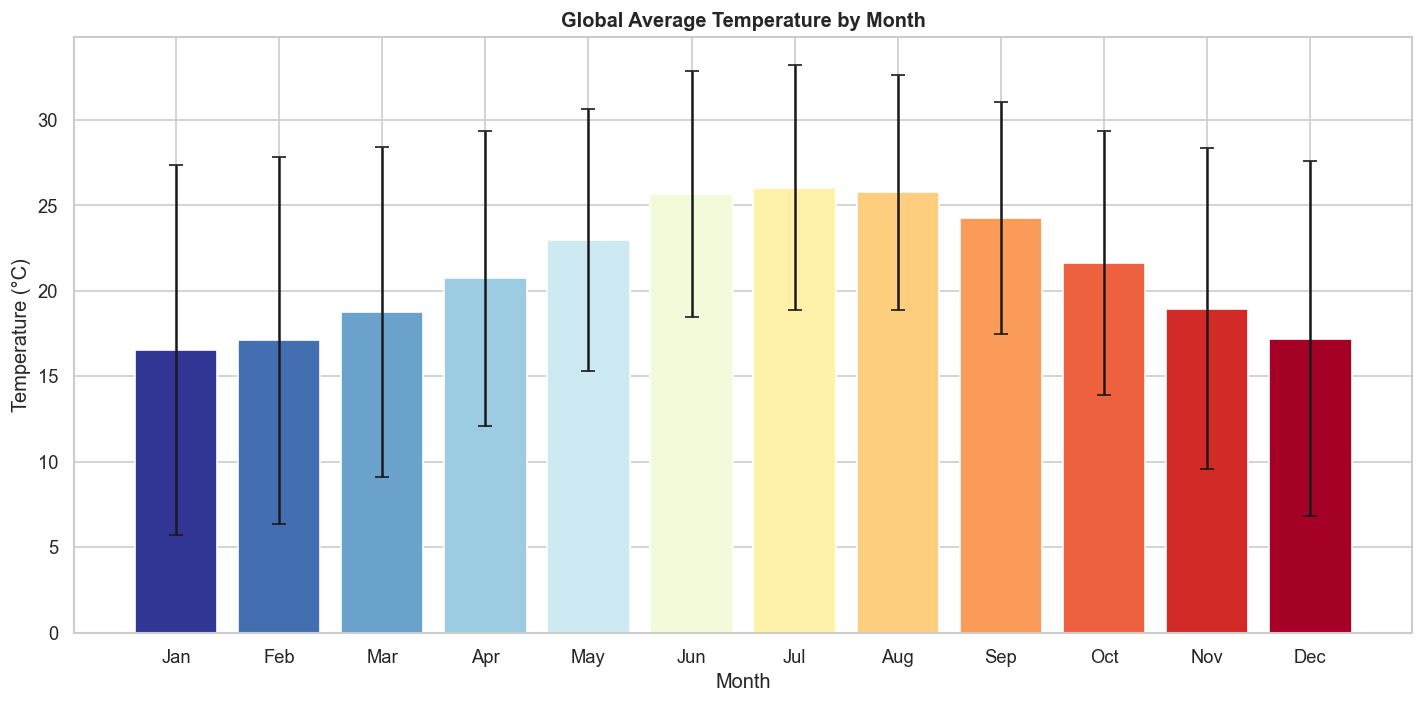


Monthly Global Temperature Stats:
      mean    std  min   max
Jan  16.52  10.84 -2.6  41.4
Feb  17.09  10.74 -2.6  37.4
Mar  18.74   9.64 -2.6  40.0
Apr  20.71   8.61 -2.6  46.2
May  22.96   7.66 -1.0  46.2
Jun  25.65   7.21 -2.6  46.2
Jul  26.02   7.18 -1.7  46.2
Aug  25.75   6.87 -0.8  46.2
Sep  24.25   6.76 -2.6  46.2
Oct  21.61   7.74 -2.6  41.8
Nov  18.95   9.39 -2.6  38.1
Dec  17.19  10.39 -2.6  41.3
 Saved: 32_monthly_global_temp.png


In [6]:
monthly_global = df.groupby('month')['temperature_celsius'].agg(
    ['mean', 'std', 'min', 'max']
).round(2)
monthly_global.index = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(monthly_global.index, monthly_global['mean'],
              yerr=monthly_global['std'],
              color=cm.RdYlBu_r(
                  np.linspace(0, 1, 12)
              ),
              edgecolor='white', capsize=4)
ax.set_title('Global Average Temperature by Month',
             fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '32_monthly_global_temp.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMonthly Global Temperature Stats:")
print(monthly_global.to_string())
print(" Saved: 32_monthly_global_temp.png")